# 第019讲 随机变量与期望

## 目标
从六个等概率状态计算分布、矩与条件期望，再用完整固定种子模拟核对。所有数据为无量纲合成教学模型，有限实验不证明极限定理。先修017至018讲；完整解释见lecture.pdf，逐步实验见lab.pdf，14题详解见answers.pdf。

## 环境与可重复运行
请重启内核并运行全部。本Notebook实际在新Python进程中的真实ipykernel InProcessKernel依序执行；浏览器UI、外进程socket与学习者Anaconda未测试。核心为标准库，绘图用Matplotlib。所有输入相对当前单元目录。

In [1]:
from pathlib import Path
from fractions import Fraction
import json, math, statistics
import matplotlib.pyplot as plt
from IPython.display import display, Image
from io import BytesIO
def show(fig):
    buffer=BytesIO()
    fig.savefig(buffer,format="png",dpi=140,bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
import experiment as e
plt.rcParams.update({"figure.figsize":(9,3.6),"axes.spines.top":False,"axes.spines.right":False})
print("CSV exists:", (Path("data")/"scenarios.csv").is_file())
x, p, groups = e.load_model()
print("values:", x, "groups:", groups)

CSV exists: True
values: [Fraction(0, 1), Fraction(0, 1), Fraction(1, 1), Fraction(1, 1), Fraction(2, 1), Fraction(4, 1)] groups: ['quiet', 'quiet', 'active', 'active', 'active', 'active']


## 1 先按状态合并概率
X相同的状态概率相加；去重后等权会改变模型。

In [2]:
mass = e.pmf(x,p)
print("PMF:", mass)
print("mean by states:", sum(v*w for v,w in zip(x,p)))
print("wrong uniform mean of distinct values:", sum(set(x))/len(set(x)))

PMF: {0.0: 0.3333333333333333, 1.0: 0.3333333333333333, 2.0: 0.16666666666666666, 4.0: 0.16666666666666666}
mean by states: 4/3
wrong uniform mean of distinct values: 7/4


## 2 CDF端点是事件定义
include=False查询严格小于阈值。图中每个右端跳跃点属于较高一级。

-1 0.0
0 0.3333333333333333
1 0.6666666666666666
2 0.8333333333333333
4 1.0
5 1.0
mass at 1: 0.3333333333333333


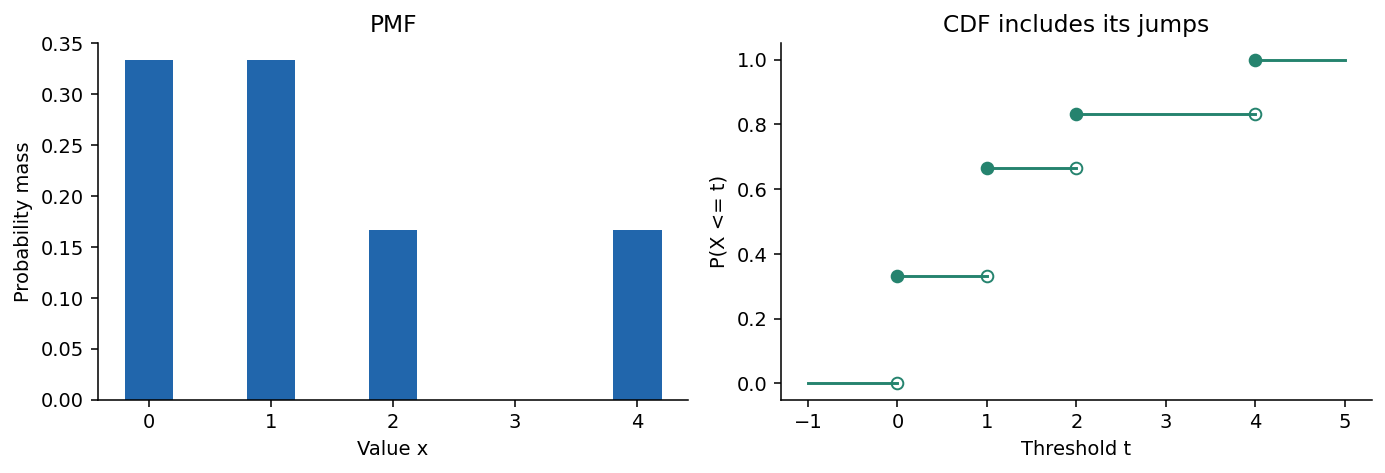

In [3]:
for t in [-1,0,1,2,4,5]:
    print(t, e.cdf(x,p,t))
print("mass at 1:", e.cdf(x,p,1)-e.cdf(x,p,1,False))
fig, ax = plt.subplots(1,2,figsize=(10,3.5))
ax[0].bar(list(mass),list(mass.values()),width=.4,color="#2166ac")
ax[0].set(xlabel="Value x",ylabel="Probability mass",title="PMF")
for a,b,height in [(-1,0,0),(0,1,1/3),(1,2,2/3),(2,4,5/6),(4,5,1)]:
    ax[1].plot([a,b],[height,height],color="#25836e")
for t in mass:
    ax[1].scatter(t,e.cdf(x,p,t),color="#25836e")
    ax[1].scatter(t,e.cdf(x,p,t,False),facecolors="white",edgecolors="#25836e")
ax[1].set(xlabel="Threshold t",ylabel="P(X <= t)",title="CDF includes its jumps")
fig.tight_layout(); show(fig); plt.close(fig)

## 3 精确矩与稳定浮点计算
用Fraction独立求和，再比较实现。此处不是从程序自身输出生成参考答案。

In [4]:
mu = sum(v*w for v,w in zip(x,p))
second = sum(v*v*w for v,w in zip(x,p))
var = sum((v-mu)**2*w for v,w in zip(x,p))
print("Exact mean, second moment, variance:", mu, second, var)
print("Float stable moments:", e.moments(x,p))
e.require(mu==Fraction(4,3) and second==Fraction(11,3) and var==Fraction(17,9), "hand calculation")
print("E[X²] vs E[X]²:",second,mu**2)

Exact mean, second moment, variance: 4/3 11/3 17/9
Float stable moments: {'mean': 1.3333333333333333, 'variance': 1.888888888888889, 'standard_deviation': 1.3743685418725535}
E[X²] vs E[X]²: 11/3 16/9


## 4 平方风险选择常数
均值不是支持集里的数，也仍可成为平方损失下最优的实数预测。

In [5]:
for a in [0,1,Fraction(4,3),2,4]:
    direct = sum((v-a)**2*w for v,w in zip(x,p))
    exact = var+(a-mu)**2
    e.require(direct==exact,"exact square-risk identity")
    print("a:",str(a),"risk:",str(exact),"float:",e.square_risk(x,p,a))

a: 0 risk: 11/3 float: 3.6666666666666665
a: 1 risk: 2 float: 2.0
a: 4/3 risk: 17/9 float: 1.888888888888889
a: 2 risk: 7/3 float: 2.333333333333333
a: 4 risk: 9 float: 9.0


## 5 条件均值要乘回组概率
两组质量不相等。比较带权重组与错误简单平均。

In [6]:
conditional = {g:e.condition(x,p,[label==g for label in groups]) for g in ("quiet","active")}
for name,item in conditional.items(): print(name,item)
print("Weighted tower:",sum(v["mass"]*v["mean"] for v in conditional.values()))
print("Wrong equal-group average:",sum(v["mean"] for v in conditional.values())/2)
group_risk=sum((v-(0 if g=="quiet" else 2))**2*w for v,w,g in zip(x,p,groups))
print("Exact group prediction risk:",group_risk,"improvement:",var-group_risk)

quiet {'mass': 0.3333333333333333, 'mean': 0.0, 'values': [0.0, 0.0], 'probabilities': [0.5, 0.5]}
active {'mass': 0.6666666666666666, 'mean': 2.0, 'values': [1.0, 1.0, 2.0, 4.0], 'probabilities': [0.25, 0.25, 0.25, 0.25]}
Weighted tower: 1.3333333333333333
Wrong equal-group average: 1.0
Exact group prediction risk: 1 improvement: 8/9


## 6 实际运行所有固定种子
四种n各24次，保留每次种子和组计数。不要删掉不接近理论值的结果。输出文件是本次生成，不是预制答案。

In [7]:
report = e.run()
output=Path("notebook_results"); output.mkdir(exist_ok=True)
(output/"report.json").write_text(json.dumps(report,ensure_ascii=False,indent=2,allow_nan=False)+"\n",encoding="utf-8")
for block in report["simulations"]:
    means=[run["mean"] for run in block["runs"]]
    print("n:",block["n"],"all seeds:",[run["seed"] for run in block["runs"]],"range:",(min(means),max(means)))

n: 30 all seeds: [193000, 193001, 193002, 193003, 193004, 193005, 193006, 193007, 193008, 193009, 193010, 193011, 193012, 193013, 193014, 193015, 193016, 193017, 193018, 193019, 193020, 193021, 193022, 193023] range: (0.9333333333333333, 1.7333333333333334)
n: 300 all seeds: [220000, 220001, 220002, 220003, 220004, 220005, 220006, 220007, 220008, 220009, 220010, 220011, 220012, 220013, 220014, 220015, 220016, 220017, 220018, 220019, 220020, 220021, 220022, 220023] range: (1.18, 1.4266666666666667)
n: 3000 all seeds: [490000, 490001, 490002, 490003, 490004, 490005, 490006, 490007, 490008, 490009, 490010, 490011, 490012, 490013, 490014, 490015, 490016, 490017, 490018, 490019, 490020, 490021, 490022, 490023] range: (1.2763333333333333, 1.3693333333333333)
n: 30000 all seeds: [3190000, 3190001, 3190002, 3190003, 3190004, 3190005, 3190006, 3190007, 3190008, 3190009, 3190010, 3190011, 3190012, 3190013, 3190014, 3190015, 3190016, 3190017, 3190018, 3190019, 3190020, 3190021, 3190022, 3190023] 

## 7 经验全期望是同一批数据的代数恒等式
每组24个点全部展示。这些范围是实际模拟散布，不是置信区间。

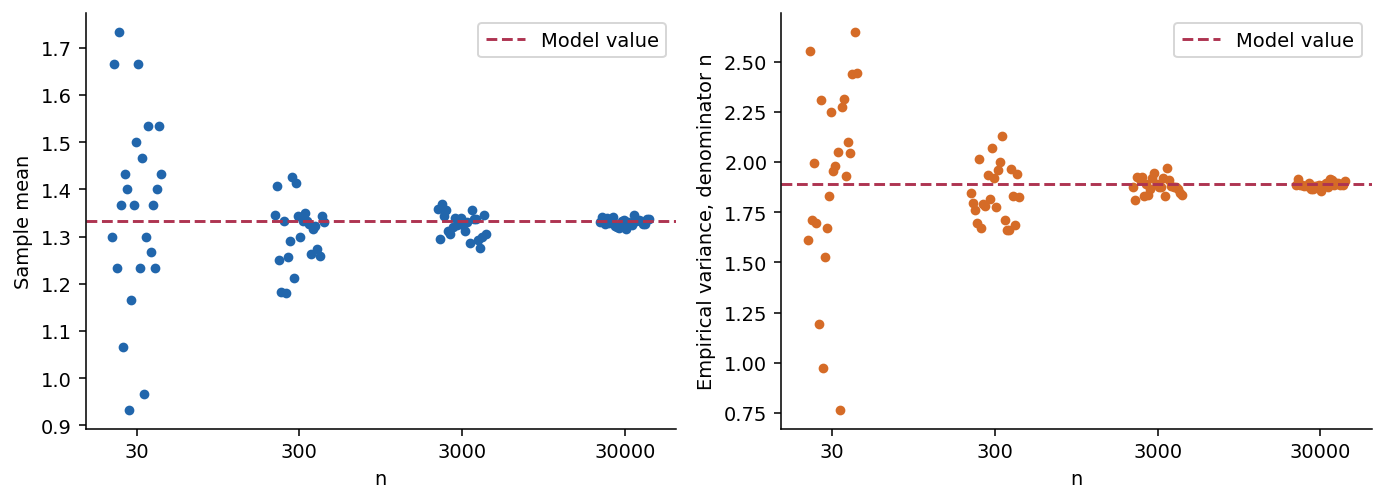

In [8]:
fig,axs=plt.subplots(1,2,figsize=(10,3.7))
for i,block in enumerate(report["simulations"]):
    jitter=[i-.15+.3*j/23 for j in range(24)]
    axs[0].scatter(jitter,[r["mean"] for r in block["runs"]],s=16,color="#2166ac")
    axs[1].scatter(jitter,[r["variance_n"] for r in block["runs"]],s=16,color="#d56b27")
    for run in block["runs"]:
        e.require(math.isclose(run["empirical_tower"],run["mean"],abs_tol=1e-14),"empirical tower")
for ax,target,label in zip(axs,[4/3,17/9],["Sample mean","Empirical variance, denominator n"]):
    ax.axhline(target,color="#ae3451",linestyle="--",label="Model value")
    ax.set(xticks=range(4),xticklabels=[30,300,3000,30000],xlabel="n",ylabel=label); ax.legend()
fig.tight_layout();show(fig);plt.close(fig)

## 8 没观察到某组，不等于模型事件概率为零
空组均值用None表示，不填0。经验重组只累加实际非空组的贡献。

In [9]:
absent=[run for run in report["small_samples"] if run["groups"]["active"]["count"]==0]
print("Absent active among 64 n=2 runs:",len(absent))
print("First actual example:",absent[0])
print("Theoretical active mean remains:",conditional["active"]["mean"])
try:
    e.condition([1,2],[1,0],[False,True])
except ValueError as err:
    print("Zero model event rejected:",str(err))

Absent active among 64 n=2 runs: 6
First actual example: {'n': 2, 'mean': 0.0, 'variance_n': 0.0, 'groups': {'quiet': {'count': 2, 'mean': 0.0}, 'active': {'count': 0, 'mean': None}}, 'empirical_tower': 0.0, 'seed': 199000}
Theoretical active mean remains: 2.0
Zero model event rejected: conditioning event has zero model probability


## 9 连续密度的三个积分
质量准确不保证矩准确。对本模型的梯形一、二阶矩有明确网格误差。

In [10]:
for row in report["continuous_quadrature"]:
    n=row["n"]
    e.require(math.isclose(row["first_moment"],7/6+1/(3*n*n),abs_tol=1e-14),"first quadrature oracle")
    e.require(math.isclose(row["second_moment"],5/3+4/(3*n*n),abs_tol=1e-14),"second quadrature oracle")
    print(row)
for u in [0,1e-12,.01,.2,.5,.9,1]:
    t=e.inverse_cdf(u)
    print("u, inverse, reconstructed:",u,t,e.continuous_cdf(t))
    e.require(math.isclose(e.continuous_cdf(t),u,abs_tol=2e-15),"inverse CDF roundtrip")
print("Actual 30000-draw moments:",report["continuous_sample"])

{'n': 4, 'mass': 1.0, 'first_moment': 1.1875, 'second_moment': 1.75, 'variance_by_moments': 0.33984375}
{'n': 16, 'mass': 1.0, 'first_moment': 1.16796875, 'second_moment': 1.671875, 'variance_by_moments': 0.3077239990234375}
{'n': 64, 'mass': 1.0, 'first_moment': 1.166748046875, 'second_moment': 1.6669921875, 'variance_by_moments': 0.3056911826133728}
{'n': 256, 'mass': 1.0, 'first_moment': 1.1666717529296875, 'second_moment': 1.66668701171875, 'variance_by_moments': 0.3055640326347202}
u, inverse, reconstructed: 0 0.0 0.0
u, inverse, reconstructed: 1e-12 3.999999999992e-12 1e-12
u, inverse, reconstructed: 0.01 0.039230484541326376 0.01
u, inverse, reconstructed: 0.2 0.6124515496597099 0.19999999999999998
u, inverse, reconstructed: 0.5 1.2360679774997896 0.49999999999999994
u, inverse, reconstructed: 0.9 1.8635642126552707 0.9
u, inverse, reconstructed: 1 2.0 1.0
Actual 30000-draw moments: {'n': 30000, 'seed': 190777, 'mean': 1.1691337475914578, 'variance_n': 0.3054184069058165}


## 10 原子、连续部分与不存在的有限平均
混合CDF在0处跳跃；重尾的总质量与一阶矩有不同极限。

Mixed CDF around zero: [(-0.1, 0.0), (0, 0.3333333333333333), (0.1, 0.39999999999999997), (1, 1.0)]
{'B': 2, 'mass': 0.5, 'truncated_first_moment': 0.6931471805599453}
{'B': 10, 'mass': 0.9, 'truncated_first_moment': 2.302585092994046}
{'B': 100, 'mass': 0.99, 'truncated_first_moment': 4.605170185988092}
{'B': 10000, 'mass': 0.9999, 'truncated_first_moment': 9.210340371976184}
{'B': 100000000.0, 'mass': 0.99999999, 'truncated_first_moment': 18.420680743952367}


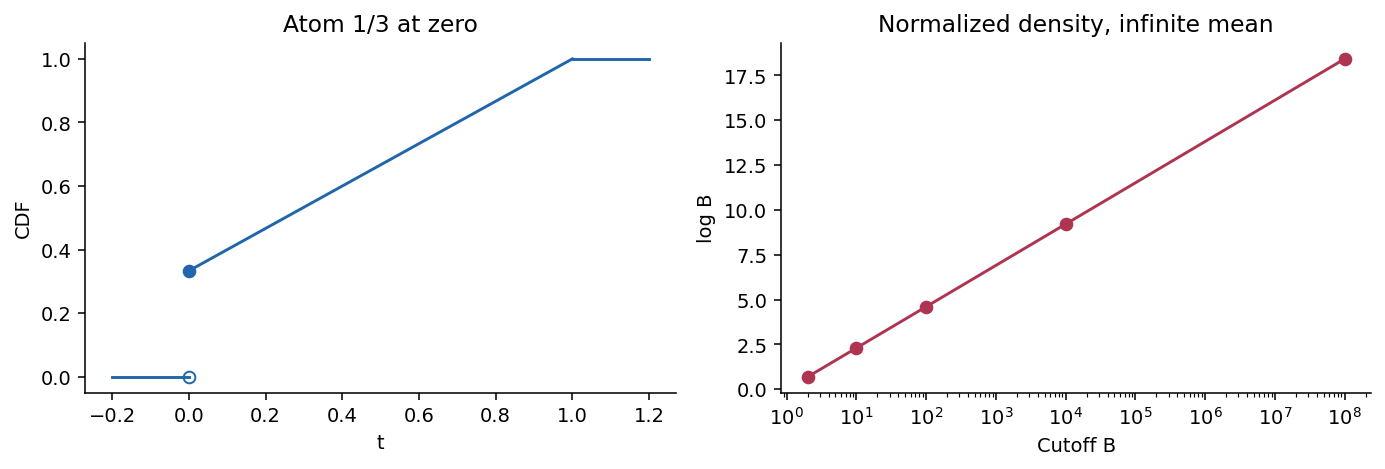

In [11]:
print("Mixed CDF around zero:",[(t,e.mixed_cdf(t)) for t in [-.1,0,.1,1]])
for row in report["heavy_tail"]: print(row)
fig,axs=plt.subplots(1,2,figsize=(10,3.5))
axs[0].plot([-.2,0],[0,0],color="#2166ac");axs[0].plot([0,1],[1/3,1],color="#2166ac");axs[0].plot([1,1.2],[1,1],color="#2166ac")
axs[0].scatter([0],[0],facecolors="white",edgecolors="#2166ac");axs[0].scatter([0],[1/3],color="#2166ac")
axs[0].set(xlabel="t",ylabel="CDF",title="Atom 1/3 at zero")
axs[1].semilogx([r["B"] for r in report["heavy_tail"]],[r["truncated_first_moment"] for r in report["heavy_tail"]],"o-",color="#ae3451")
axs[1].set(xlabel="Cutoff B",ylabel="log B",title="Normalized density, infinite mean")
fig.tight_layout();show(fig);plt.close(fig)

## 11 浮点损失发生在何处
参考平移避免原始大矩相减；输入已经舍入成常数后无法恢复。分母n与n-1描述不同任务，不在此证明无偏性。

{
  "offset": 1000000000000.0,
  "naive_second_moment_difference": -134217728.0,
  "reference_shifted_variance": 1.888888888888889,
  "exact_variance": "17/9",
  "huge_offset": 1e+18,
  "huge_distinct_values": 1
}
Same six values: pvariance and variance: 17/9 34/15


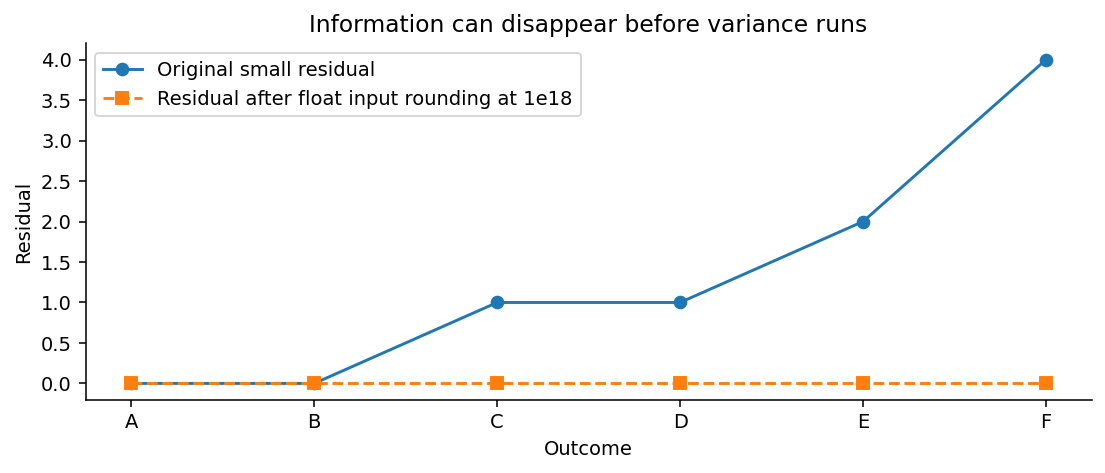

In [12]:
print(json.dumps(report["cancellation"],ensure_ascii=False,indent=2))
print("Same six values: pvariance and variance:",statistics.pvariance(x),statistics.variance(x))
fig,ax=plt.subplots(figsize=(8,3.5))
small=[float(v) for v in x]
large=[(1e18+float(v))-1e18 for v in x]
ax.plot(list("ABCDEF"),small,"o-",label="Original small residual")
ax.plot(list("ABCDEF"),large,"s--",label="Residual after float input rounding at 1e18")
ax.set(xlabel="Outcome",ylabel="Residual",title="Information can disappear before variance runs");ax.legend()
fig.tight_layout();show(fig);plt.close(fig)

## 12 失败案例与交叉核对
检查都用显式require或raise，python -O不能移除。外层检查不能识别任意回调内部已悄悄丢失的信息，扩展回调时也须验证运算。

In [13]:
print("Exact and floating crosschecks:",report["exact_and_float_crosschecks"])
print("Boundary checks:",e.boundary_audit())
for bad in [True,"1",complex(1,0),float("nan")]:
    try: e.model([bad],[1])
    except (ValueError,TypeError) as err: print(type(bad).__name__,"rejected",str(err))

Exact and floating crosschecks: 1120
Boundary checks: {'expected_rejections': 49, 'accepted_or_sentinel_checks': 7}
bool rejected values must be an ordinary finite real number
str rejected values must be an ordinary finite real number
complex rejected values must be an ordinary finite real number
float rejected values must be finite


## 结论与下一步
已知模型均值4/3、方差17/9；组均值0与2须以1/3与2/3加权，条件预测风险1。连续模型均值7/6、方差11/36；本次30000样本只给有限估计。模型矩、网格近似与样本估计是三个层次，均应保留各自来源与误差。请完成answers.pdf中14题；常见分布见020，联合结构见021，LLN/CLT见022。

来源：本单元source-checks.json中的MIT18.05、MIT6.041和Python3.12官方材料。